In [1]:
# TODO: current 4.59 it/s
# TODO: word tokenizer
# TODO: visualize attention
# TODO: visualize gradient issues
# TODO: without bias?
# TODO: make sampling faster
# TODO: how to measure model quality?
# TODO: karpathy tokenizer video
# TODO: add validation set / step
# TODO: load gpt 2 checkpoint 

CONFIG = {
    "seq_len": 128, # TODO: call block_size
    "batch_size": 2048 *2, #128,,
    "embed_size": 64, #
    "num_heads": 2, # TODO: why can't I use 6 heads?
    "num_layers": 2,
    "learning_rate": 3e-3,
    "max_steps": 500,
    #"dropout": 0.1,
    "gradient_accumulation_steps": 1,
    "tune_batch_size": True,
    "layer_norm_enabled": True
}

"""
CONFIG = {
    "seq_len": 128,  # Increased from 10 - critical for learning context
    "batch_size": 64,  # Increased from 4 - better gradient estimates
    "embed_size": 128,  # Increased from 32 - more model capacity
    "num_heads": 4,  # Increased from 2 - better attention patterns (embed_size must be divisible)
    "num_layers": 4,  # Increased from 2 - deeper model for better learning
    "dropout": 0.1,  # Enable dropout for regularization
    "learning_rate": 3e-4,  # Standard for transformers (AdamW)
    "weight_decay": 0.1,  # L2 regularization
    "max_steps": 1000,  # More training steps
}
"""


'\nCONFIG = {\n    "seq_len": 128,  # Increased from 10 - critical for learning context\n    "batch_size": 64,  # Increased from 4 - better gradient estimates\n    "embed_size": 128,  # Increased from 32 - more model capacity\n    "num_heads": 4,  # Increased from 2 - better attention patterns (embed_size must be divisible)\n    "num_layers": 4,  # Increased from 2 - deeper model for better learning\n    "dropout": 0.1,  # Enable dropout for regularization\n    "learning_rate": 3e-4,  # Standard for transformers (AdamW)\n    "weight_decay": 0.1,  # L2 regularization\n    "max_steps": 1000,  # More training steps\n}\n'

In [2]:
import torch
DEVICE = torch.device("mps")

Load dataset:

In [3]:
import requests
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATASET_TEXT = requests.get(url).text
print("n_tokens", len(DATASET_TEXT))

n_tokens 1115394


In [4]:
with open("data/lotr.txt", "r", encoding="latin-1") as f: DATASET_TEXT = f.read()

In [5]:
chars = sorted(list(set(DATASET_TEXT)))
len(chars), chars

(81,
 ['\n',
  ' ',
  '!',
  '"',
  "'",
  '(',
  ')',
  '*',
  ',',
  '-',
  '.',
  '/',
  '0',
  '1',
  '2',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9',
  ':',
  ';',
  '=',
  '?',
  'A',
  'B',
  'C',
  'D',
  'E',
  'F',
  'G',
  'H',
  'I',
  'J',
  'K',
  'L',
  'M',
  'N',
  'O',
  'P',
  'Q',
  'R',
  'S',
  'T',
  'U',
  'V',
  'W',
  'X',
  'Y',
  'Z',
  'a',
  'b',
  'c',
  'd',
  'e',
  'f',
  'g',
  'h',
  'i',
  'j',
  'k',
  'l',
  'm',
  'n',
  'o',
  'p',
  'q',
  'r',
  's',
  't',
  'u',
  'v',
  'w',
  'x',
  'y',
  'z',
  '½',
  '¿',
  'ï'])

Create tokenizer:

In [6]:
ctoi = {c:i for i, c in enumerate(chars)}
itoc = {i:c for i, c in enumerate(chars)}
encode = lambda text: [ctoi[c] for c in text]
decode = lambda tokens: "".join([itoc[i] for i in tokens])
decode(encode("hello world"))

'hello world'

Create token embedding table:

In [7]:
import torch
import torch.nn as nn

vocab_size = len(ctoi)
embed_size = CONFIG["embed_size"]
CONFIG["vocab_size"] = vocab_size

seq_len = CONFIG["seq_len"]
pad = lambda text: " " * max(0, seq_len - len(text)) + text
text = pad("hello")
tokens = torch.tensor(encode(text))
token_embedding_table = nn.Embedding(vocab_size, embed_size)
tokens_emb = token_embedding_table(tokens)
tokens_emb.shape, tokens_emb

(torch.Size([128, 64]),
 tensor([[-0.6908, -1.0444,  1.0361,  ..., -1.8697, -0.6621, -1.0840],
         [-0.6908, -1.0444,  1.0361,  ..., -1.8697, -0.6621, -1.0840],
         [-0.6908, -1.0444,  1.0361,  ..., -1.8697, -0.6621, -1.0840],
         ...,
         [ 0.8975,  0.0561,  0.3482,  ..., -1.5552,  1.7443,  0.1305],
         [ 0.8975,  0.0561,  0.3482,  ..., -1.5552,  1.7443,  0.1305],
         [-1.0055, -1.0346,  0.1446,  ..., -1.3160, -1.1928,  1.6351]],
        grad_fn=<EmbeddingBackward0>))

Create position embedding table:

In [8]:
seq_len = CONFIG["seq_len"]
embed_size = CONFIG["embed_size"]

position_embedding_table = nn.Embedding(seq_len, embed_size)
positions = torch.arange(seq_len)
positions_emb = position_embedding_table(positions)
positions_emb.shape, positions_emb

(torch.Size([128, 64]),
 tensor([[-0.2962,  0.5056,  0.5876,  ...,  1.7618,  0.1677, -0.7675],
         [-0.4440, -1.8221,  0.2493,  ..., -0.3456,  0.4789,  0.6857],
         [ 1.8023, -0.8117, -0.6599,  ..., -0.8381, -0.9310, -1.8090],
         ...,
         [-1.1888, -0.1507, -0.2380,  ..., -0.4711,  0.1100,  0.3024],
         [ 0.7893,  1.7447,  0.2151,  ...,  0.5030,  0.0906,  0.1639],
         [-1.3452, -0.7560,  1.2639,  ..., -1.1225, -0.3819,  0.1523]],
        grad_fn=<EmbeddingBackward0>))

Test combining token embeddings and positions embeddings:

In [9]:
x = tokens_emb + positions_emb
x.shape, x

(torch.Size([128, 64]),
 tensor([[-0.9870, -0.5389,  1.6237,  ..., -0.1078, -0.4943, -1.8515],
         [-1.1348, -2.8666,  1.2855,  ..., -2.2153, -0.1831, -0.3983],
         [ 1.1115, -1.8561,  0.3762,  ..., -2.7078, -1.5931, -2.8930],
         ...,
         [-0.2913, -0.0946,  0.1102,  ..., -2.0263,  1.8543,  0.4329],
         [ 1.6868,  1.8008,  0.5633,  ..., -1.0522,  1.8349,  0.2943],
         [-2.3507, -1.7906,  1.4085,  ..., -2.4385, -1.5747,  1.7874]],
        grad_fn=<AddBackward0>))

Create batch sampler:

In [10]:
DATASET_TOKENS = encode(DATASET_TEXT)

def sample_batch(batch_len):
    seq_len = CONFIG["seq_len"]
    xs, ys = [], []
    for _ in range(batch_len):
        offset_idx = torch.randint(len(DATASET_TOKENS) - seq_len, (1,))
        x = DATASET_TOKENS[offset_idx:offset_idx+seq_len]
        y = DATASET_TOKENS[offset_idx+1:offset_idx+seq_len+1]
        xs.append(x)
        ys.append(y)
    return torch.tensor(xs), torch.tensor(ys)

x, y = sample_batch(10)
x.shape, x, y.shape, y


(torch.Size([10, 128]),
 tensor([[ 1, 70, 52,  ...,  1, 58, 52],
         [ 1, 47, 56,  ..., 59, 66, 65],
         [71, 76,  1,  ..., 62, 10,  3],
         ...,
         [55, 66, 72,  ..., 69, 63, 66],
         [ 1, 54, 52,  ...,  0, 26, 64],
         [ 8,  1, 58,  ..., 65, 62,  1]]),
 torch.Size([10, 128]),
 tensor([[70, 52, 60,  ..., 58, 52, 71],
         [47, 56, 69,  ..., 66, 65, 56],
         [76,  1, 65,  ..., 10,  3,  0],
         ...,
         [66, 72, 53,  ..., 63, 66, 72],
         [54, 52, 64,  ..., 26, 64, 69],
         [ 1, 58, 69,  ..., 62,  1, 55]]))

Test decoding batch:

In [11]:
for i in range(x.shape[0]):
    x_tokens = x[i].tolist()
    y_tokens = y[i].tolist()
    print(f"x {i}: {decode(x_tokens)}")
    print(f"y {i}: {decode(y_tokens)}")
    print()

x 0:  said no more; but Frodo could see in the lantern-light that the man was still eyeing them curiously. He was glad to hear the ga
y 0: said no more; but Frodo could see in the lantern-light that the man was still eyeing them curiously. He was glad to hear the gat

x 1:  Very bright was that sword when it was made whole again; the light of the sun shone redly in it, and the light of the moon shon
y 1: Very bright was that sword when it was made whole again; the light of the sun shone redly in it, and the light of the moon shone

x 2: ty night,
when pools are black and trees are bare,
'tis evil in the Wild to fare.

But that I am afraid will be just your luck."
y 2: y night,
when pools are black and trees are bare,
'tis evil in the Wild to fare.

But that I am afraid will be just your luck."


x 3: growth."
"Whatever it may be," said Pippin, "they will be marvellous trees indeed if they can offer any rest at night, except to
y 3: rowth."
"Whatever it may be," said Pippin, "they will 

In [12]:
batch_size = CONFIG["batch_size"]
seq_len = CONFIG["seq_len"]
x, _ = sample_batch(batch_size)
x_emb = token_embedding_table(x)
positions = torch.arange(seq_len)
pos_emb = position_embedding_table(positions)
x = x_emb + pos_emb
x.shape, x[0][0]

(torch.Size([4096, 128, 64]),
 tensor([ 0.5718,  0.2203, -0.8013, -0.9807, -0.0616, -1.3209, -2.6004,  0.3190,
         -0.4661, -1.3928,  0.3356, -2.0932, -0.7759,  0.4009,  0.5657, -0.0849,
         -0.8475,  0.8393,  0.7844, -0.1988,  0.0575,  1.2542,  0.6827, -1.0709,
         -0.4389,  2.2632,  1.1536,  0.4286, -0.7976,  0.2198,  0.9623,  3.7332,
         -2.8806,  0.4046, -0.6165, -0.8320,  1.8377,  2.8640,  0.6189, -0.3310,
          0.4141, -0.0906,  0.1169,  0.1081, -1.0991, -0.8600, -2.2735, -0.9861,
         -1.0584, -0.1474,  2.3936,  3.1361,  0.2904, -1.6782,  3.2899,  1.0539,
          0.3532, -0.0518, -1.2124,  1.8019, -3.1252,  0.8307, -0.2574, -1.3883],
        grad_fn=<SelectBackward0>))

In [13]:
qkv_shape = (CONFIG["embed_size"], CONFIG["embed_size"]) # TODO; call embed_dim
Wq = torch.randn(qkv_shape)
Wk = torch.randn(qkv_shape)
Wv = torch.randn(qkv_shape)

In [14]:
Q = x @ Wq
K = x @ Wk
V = x @ Wv
Q.shape, K.shape, V.shape

(torch.Size([4096, 128, 64]),
 torch.Size([4096, 128, 64]),
 torch.Size([4096, 128, 64]))

In [15]:
Kt = K.transpose(-2, -1)
Kt.shape

torch.Size([4096, 64, 128])

In [16]:
QKt = Q @ Kt # (B, T, C) @ (B, C, T) -> (B, T, T)
QKt.shape, QKt[0][0]

(torch.Size([4096, 128, 128]),
 tensor([ -967.5300,  1525.0210,   123.9896,  -866.8347,  1020.9528,    17.4861,
             5.6586,  -697.2247, -1408.0853,  -177.4483, -1892.2479,   891.6606,
           579.2111,  -438.5028, -1468.0541,  -906.4223,  1023.4297,  1045.1719,
          1430.6947, -1320.4062, -1038.3079,   227.9214,   269.9073,   478.6634,
           -96.1249,   888.9240,  -504.1384,   257.4310,  2119.9885,  -259.9669,
         -1929.3273,  -484.7458,  -988.7449,  1136.5540,  -654.8310,  1647.5731,
          -257.1855,   241.3282,  -582.8617,  1107.5623,   521.0378, -1448.5803,
          2520.2241,   -33.7892,   415.4035,  1488.9728,  -934.9102,  2711.4341,
          -403.5269,   435.4262, -1255.8223,  -299.7177,  1980.7532,  -913.7332,
           570.7371,  2018.9202,   931.2300,  -926.6498,  1570.3108,   -62.3470,
         -1044.9387,  -365.5428,    60.0048,  -771.1254,   100.2122,   553.1615,
          1461.5897,   565.6934,   505.8240, -1132.6390,   -95.6403,   329.621

In [17]:
QKt_scaled = QKt / torch.sqrt(torch.tensor(embed_size))
QKt_scaled.shape, QKt_scaled[0][0]

(torch.Size([4096, 128, 128]),
 tensor([-120.9413,  190.6276,   15.4987, -108.3543,  127.6191,    2.1858,
            0.7073,  -87.1531, -176.0107,  -22.1810, -236.5310,  111.4576,
           72.4014,  -54.8129, -183.5068, -113.3028,  127.9287,  130.6465,
          178.8368, -165.0508, -129.7885,   28.4902,   33.7384,   59.8329,
          -12.0156,  111.1155,  -63.0173,   32.1789,  264.9986,  -32.4959,
         -241.1659,  -60.5932, -123.5931,  142.0692,  -81.8539,  205.9466,
          -32.1482,   30.1660,  -72.8577,  138.4453,   65.1297, -181.0725,
          315.0280,   -4.2236,   51.9254,  186.1216, -116.8638,  338.9293,
          -50.4409,   54.4283, -156.9778,  -37.4647,  247.5941, -114.2167,
           71.3421,  252.3650,  116.4038, -115.8312,  196.2888,   -7.7934,
         -130.6173,  -45.6929,    7.5006,  -96.3907,   12.5265,   69.1452,
          182.6987,   70.7117,   63.2280, -141.5799,  -11.9550,   41.2027,
          203.1173,   -1.4897, -134.5369,  -66.4691,   43.5361,  -23.

In [18]:
tril = torch.tril(torch.ones((seq_len, seq_len)))
tril

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 0.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])

In [19]:
mask = tril == 0
mask

tensor([[False,  True,  True,  ...,  True,  True,  True],
        [False, False,  True,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True],
        ...,
        [False, False, False,  ..., False,  True,  True],
        [False, False, False,  ..., False, False,  True],
        [False, False, False,  ..., False, False, False]])

In [20]:
QKt_scaled_masked = QKt_scaled.masked_fill(mask, float("-inf"))
QKt_scaled_masked.shape, QKt_scaled_masked[0]

(torch.Size([4096, 128, 128]),
 tensor([[-120.9413,      -inf,      -inf,  ...,      -inf,      -inf,
               -inf],
         [  85.4769,  -64.5029,      -inf,  ...,      -inf,      -inf,
               -inf],
         [ 197.7722,   24.0167,   13.4903,  ...,      -inf,      -inf,
               -inf],
         ...,
         [-212.6322,   94.6905,  240.4922,  ...,  -75.9665,      -inf,
               -inf],
         [ 154.9818,   63.3404,   84.9056,  ...,   93.5322,   53.4721,
               -inf],
         [-136.1043,   24.1599,  -88.7115,  ..., -104.5762,   10.6937,
            17.8721]], grad_fn=<SelectBackward0>))

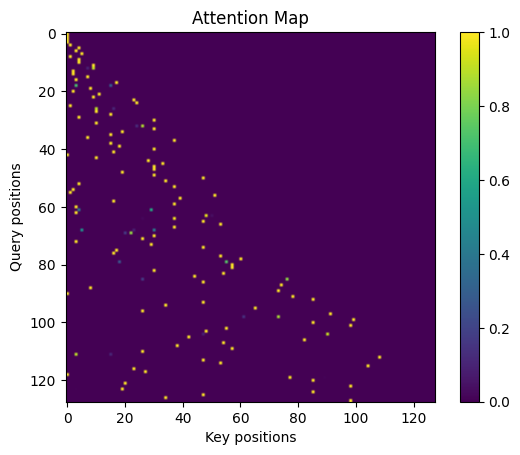

In [21]:
from torch.nn import functional as F
import matplotlib.pyplot as plt

attention = F.softmax(QKt_scaled_masked, dim=-1)

plt.imshow(attention[0].detach().cpu(), cmap='viridis')
plt.colorbar()
plt.title("Attention Map")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.show()

In [22]:
output = attention @ V
output.shape

torch.Size([4096, 128, 64])

In [23]:
ffn1 = nn.Linear(embed_size, embed_size * 4)
gelu = nn.GELU()
ffn2 = nn.Linear(embed_size * 4, embed_size)
n_heads = CONFIG["num_heads"]
head_size = embed_size // n_heads
lm_head = nn.Linear(embed_size, head_size)
output_head = lm_head(ffn2(gelu(ffn1(output))))
output_head.shape, output_head

(torch.Size([4096, 128, 32]),
 tensor([[[ 8.7412e-02, -7.3147e-01,  8.0837e-01,  ...,  2.3141e+00,
           -9.1035e-01,  7.1097e-01],
          [ 8.7412e-02, -7.3147e-01,  8.0837e-01,  ...,  2.3141e+00,
           -9.1035e-01,  7.1097e-01],
          [ 8.7412e-02, -7.3147e-01,  8.0837e-01,  ...,  2.3141e+00,
           -9.1035e-01,  7.1097e-01],
          ...,
          [-4.3063e+00, -2.1353e+00, -1.2778e+00,  ...,  2.4594e+00,
           -4.3988e-01, -7.4806e-01],
          [-9.4497e-01, -1.8692e+00,  2.7613e+00,  ...,  1.1891e+00,
            3.9521e-01,  9.9852e-01],
          [ 1.1579e+00, -1.1413e+00,  2.2770e+00,  ...,  3.7272e+00,
           -3.2097e+00,  3.0028e+00]],
 
         [[-1.0129e-01, -1.2110e+00,  1.2827e+00,  ...,  3.1284e+00,
           -1.1867e+00,  5.2667e-01],
          [-1.0129e-01, -1.2110e+00,  1.2827e+00,  ...,  3.1284e+00,
           -1.1867e+00,  5.2667e-01],
          [-1.0129e-01, -1.2110e+00,  1.2827e+00,  ...,  3.1284e+00,
           -1.1867e+00,  5.

In [24]:
class AttentionHead(nn.Module):
    def __init__(self, head_size):
        nn.Module.__init__(self)
        
        self.head_size = head_size
        embed_size = CONFIG["embed_size"]

        #self.W_q = nn.Linear(embed_size, head_size)
        #self.W_k = nn.Linear(embed_size, head_size)
        #self.W_v = nn.Linear(embed_size, head_size)

        self.W_qkv = nn.Linear(embed_size, head_size * 3)

        seq_len = CONFIG["seq_len"]
        self.register_buffer("tril", torch.tril(torch.ones(seq_len, seq_len)))
        
    def forward(self, x):
        B, T, C = x.shape
        #print("WORKED BTC", B, T, C)

        #Q = self.W_q(x)
        #K = self.W_k(x)
        #V = self.W_v(x)

        QKV = self.W_qkv(x)
        Q, K, V = torch.chunk(QKV, 3, dim=-1)
        
        Kt = K.transpose(-2, -1)
        QKt = Q @ Kt
        QKt_scaled = QKt / torch.sqrt(torch.tensor(self.head_size))
        #mask = self.tril == 0

        mask = self.tril[:T, :T].to(x.device).bool()   # (T, T)
        #mask = mask.unsqueeze(0)   # (1, 1, T, T) if needed
        #print("MASK", mask.shape)
        #print("QKt_scaled", QKt_scaled.shape)

        QKt_masked = QKt_scaled.masked_fill(~mask, float("-inf"))
        attention = F.softmax(QKt_masked, dim=-1) # TODO: confirm this
        out = attention @ V

        return out

x, y = sample_batch(1)
x = token_embedding_table(x)
out = AttentionHead(3)(x)
out.shape, out

(torch.Size([1, 128, 3]),
 tensor([[[ 5.2695e-01, -1.7365e-01, -8.4743e-01],
          [ 1.3693e-01,  8.8862e-02, -7.9692e-01],
          [ 7.2644e-02, -3.4586e-02, -5.7272e-01],
          [-2.2780e-01,  2.7071e-01, -1.2809e-01],
          [-1.5066e-01,  3.4711e-01, -2.3760e-01],
          [-9.9522e-02,  7.9921e-02, -1.7085e-01],
          [-2.8849e-01,  1.0421e-02, -2.7240e-01],
          [-5.4161e-01, -3.6988e-02, -1.7143e-01],
          [-4.2526e-01,  2.3449e-01, -7.0124e-02],
          [-2.6654e-01,  1.8915e-01, -2.3822e-02],
          [-1.6024e-01,  2.0059e-01, -1.5649e-01],
          [-2.3858e-01,  2.4780e-01, -1.6482e-01],
          [-2.7377e-01,  2.8278e-01, -1.2166e-01],
          [-1.2365e-01,  3.1234e-02, -1.8506e-01],
          [-3.0016e-01,  3.9102e-01, -5.8731e-02],
          [-3.5884e-01,  2.0986e-01, -5.3803e-02],
          [-3.3001e-01,  2.2436e-01, -2.3018e-02],
          [-3.5837e-01,  1.1505e-01, -5.2760e-02],
          [-2.8224e-01,  1.4802e-01,  6.7338e-03],
     

In [25]:
class MultiHeadAttention(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        
        n_heads = CONFIG["num_heads"]
        embed_size = CONFIG["embed_size"]
        head_size = embed_size // n_heads
        self.heads = nn.ModuleList([AttentionHead(head_size) for _ in range(n_heads)])
        self.W_o = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        outs = []
        for head in self.heads: # TODO: for here?
            out = head(x)
            outs.append(out)
        mha_out = torch.concat(outs, dim=-1)
        mha_out = self.W_o(mha_out)
        return mha_out

x, _ = sample_batch(1)
x = token_embedding_table(x)
out = MultiHeadAttention()(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[ 0.3943,  0.1178, -0.1098,  ...,  0.3231, -0.0748,  0.0756],
          [-0.1464, -0.1129,  0.1890,  ...,  0.4069, -0.3138, -0.2709],
          [-0.2897, -0.0403,  0.2175,  ...,  0.1080, -0.0202, -0.1482],
          ...,
          [-0.0310,  0.0166, -0.1120,  ...,  0.0626,  0.0406, -0.0113],
          [ 0.0490,  0.0478, -0.0943,  ...,  0.0954,  0.0322, -0.0483],
          [ 0.0403,  0.0011, -0.1841,  ...,  0.1091,  0.0212,  0.0229]]],
        grad_fn=<ViewBackward0>))

In [26]:
a = torch.randn((3, 3))
a

tensor([[ 0.7519, -1.3229, -0.4889],
        [-1.6826, -0.7182,  1.2561],
        [ 1.3570, -0.8860, -0.9761]])

In [27]:
tril = torch.tril(torch.ones(3, 3))
tril

tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]])

In [28]:
mask = tril == 0
mask

tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])

In [29]:
a.masked_fill(mask, float("-inf"))

tensor([[ 0.7519,    -inf,    -inf],
        [-1.6826, -0.7182,    -inf],
        [ 1.3570, -0.8860, -0.9761]])

In [30]:
class FastMultiHeadAttention(nn.Module):
    def __init__(self, n_heads):
        nn.Module.__init__(self)
        embed_size = CONFIG["embed_size"]
        block_size = CONFIG["seq_len"]
        head_size = embed_size // n_heads
        self.n_heads = n_heads
        self.head_size = head_size
        self.W_qkv = nn.Linear(embed_size, embed_size * 3)
        self.W_o = nn.Linear(embed_size, embed_size)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        QKV = self.W_qkv(x) # (B, T, 3 * embed_size)
        Q, K, V = torch.chunk(QKV, 3, dim=-1)
        Q = Q.view(B, T, self.n_heads, self.head_size).transpose(1, 2)
        K = K.view(B, T, self.n_heads, self.head_size).transpose(1, 2)
        V = V.view(B, T, self.n_heads, self.head_size).transpose(1, 2)
        Kt = K.transpose(-2, -1)
        QKt = Q @ Kt
        QKt_scaled = QKt / torch.sqrt(torch.tensor(self.head_size)).to(x.device)
        mask = self.tril[:T, :T].bool().unsqueeze(0).unsqueeze(0)
        QKt_masked = QKt_scaled.masked_fill(~mask, float("-inf"))
        attention = F.softmax(QKt_masked, dim=-1)
        V_scaled = attention @ V # (B, n_heads, T, head_size)
        V_scaled_t = V_scaled
        V_scaled_t_realigned = V_scaled_t.transpose(1, 2).contiguous().view(B, T, C)
        output = self.W_o(V_scaled_t_realigned) 
        return output

x, _ = sample_batch(1)
x = token_embedding_table(x)
out = FastMultiHeadAttention(2)(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[ 0.2862, -0.5415,  0.3020,  ...,  0.2259, -0.7605, -0.4482],
          [-0.0497,  0.0303,  0.5759,  ...,  0.0130, -0.3766, -0.2394],
          [-0.0459, -0.0819,  0.2572,  ..., -0.0434, -0.3542, -0.2128],
          ...,
          [-0.0428, -0.0323,  0.0187,  ...,  0.1606, -0.2708,  0.0994],
          [-0.0478, -0.0472,  0.0524,  ...,  0.1794, -0.2704, -0.0100],
          [-0.0526, -0.0493, -0.0466,  ...,  0.1457, -0.2115,  0.0985]]],
        grad_fn=<ViewBackward0>))

In [31]:
class FeedForward(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        
        embed_size = CONFIG["embed_size"]
        self.ffn1 = nn.Linear(embed_size, embed_size * 4)
        self.gelu = nn.GELU()
        self.ffn2 = nn.Linear(embed_size * 4, embed_size)

    def forward(self, x):
        x = self.ffn1(x)
        x = self.gelu(x)
        x = self.ffn2(x)
        return x

x,y = sample_batch(1)
x = token_embedding_table(x)
mha_out = MultiHeadAttention()(x)
out = FeedForward()(mha_out)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[-0.0209, -0.0810, -0.0393,  ...,  0.1050,  0.0284,  0.0691],
          [ 0.0701, -0.0103, -0.0151,  ...,  0.0867, -0.0051,  0.1261],
          [ 0.0924, -0.0287, -0.0036,  ...,  0.0739, -0.0175,  0.0856],
          ...,
          [ 0.0375,  0.0011,  0.0057,  ...,  0.0479, -0.0389,  0.1130],
          [ 0.0410,  0.0018,  0.0103,  ...,  0.0455, -0.0386,  0.1189],
          [ 0.0272,  0.0111,  0.0109,  ...,  0.0481, -0.0333,  0.1321]]],
        grad_fn=<ViewBackward0>))

In [32]:
class Block(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.head = FastMultiHeadAttention(CONFIG["num_heads"])
        self.ffn = FeedForward()
        self.ln1 = nn.LayerNorm(embed_size)
        self.ln2 = nn.LayerNorm(embed_size)

    def forward(self, x):
        if CONFIG["layer_norm_enabled"]:
            x = x + self.head(self.ln1(x))  # Normalize input to attention
        else:
            x = x + self.head(x)
        
        if CONFIG["layer_norm_enabled"]:
            x = x + self.ffn(self.ln2(x))  # Normalize input to FFN
        else:
            x = x + self.ffn(x)
        return x

x, y = sample_batch(1)
x = token_embedding_table(x)
out = Block()(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[ 0.2049, -0.1376,  0.3741,  ...,  0.5176, -0.2214, -0.2704],
          [ 1.1035,  0.5512,  0.3340,  ...,  0.1651,  1.5560,  0.9703],
          [-0.7320, -1.9791,  1.3141,  ...,  0.4050, -1.3084,  1.7863],
          ...,
          [-1.0508, -1.6264, -0.1773,  ..., -1.5290, -1.3406,  1.6040],
          [-0.4754, -0.1997,  0.3845,  ...,  0.5825,  0.1979,  0.3220],
          [-0.9323, -0.8826,  0.8357,  ..., -1.8748, -0.1765, -0.9060]]],
        grad_fn=<AddBackward0>))

In [33]:
tokens = encode(pad("hello"))
tokens_t = torch.tensor(tokens)
tokens_t = tokens_t.view(1, seq_len)
tokens_t

tensor([[ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, 59, 56, 63,
         63, 66]])

In [34]:
class Transformer(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)

        self.token_embedding_table = nn.Embedding(vocab_size, embed_size)
        self.position_embedding_table = nn.Embedding(CONFIG["seq_len"], embed_size)

        # TODO: seq vs parallel
        self.blocks = nn.ModuleList([Block() for _ in range(CONFIG["num_layers"])])
        self.lm_head = nn.Linear(CONFIG["embed_size"], CONFIG["vocab_size"])
        self.ln_final = nn.LayerNorm(embed_size)

    def forward(self, x):
        B, T = x.shape
        tok_emb = self.token_embedding_table(x)        # (B, T, C)
        pos = torch.arange(T, device=x.device)         # (T,)
        pos_emb = self.position_embedding_table(pos)   # (T, C)
        pos_emb = pos_emb.unsqueeze(0)                 # (1, T, C) -> broadcasts over batch
        x = tok_emb + pos_emb      
        for block in self.blocks: x = block(x)
        if CONFIG["layer_norm_enabled"]: x = self.ln_final(x)
        x = self.lm_head(x)
        return x

    @torch.no_grad()
    def generate(self, text, max_len=20):
        device = next(self.parameters()).device
        seq_len = CONFIG["seq_len"]
        tokens = encode(text)
        tokens_t = torch.tensor(tokens).to(device)
        tokens_t = tokens_t.unsqueeze(0)#view(1, -1)
        output_tokens = []
        while len(output_tokens) < max_len:
            logits = self(tokens_t)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx = torch.multinomial(probs, num_samples=1)
            idx = idx.squeeze().item()
            tokens.append(idx)
            tokens = tokens[-seq_len:]
            tokens_t = torch.tensor(tokens).to(device).unsqueeze(0)
            #tokens_t = tokens_t.view(1, seq_len)
            output_tokens.append(idx)
        text = decode(output_tokens)
        return text


x, y = sample_batch(1)
out = Transformer()(x)
out.shape, out[0][0]

#text = Transformer().generate("hello")
#print(text)

(torch.Size([1, 128, 81]),
 tensor([-3.6582e-01,  4.8137e-01, -1.5965e-01, -5.6166e-01,  7.6514e-01,
         -4.1382e-01,  4.5001e-02,  5.4517e-01,  1.0505e+00, -4.9206e-01,
         -7.0859e-01,  3.9763e-02,  4.4549e-01,  7.2115e-01,  3.8003e-01,
          7.3574e-01, -4.5004e-01,  3.7752e-02, -2.2595e-01, -2.8129e-01,
         -8.0676e-01,  3.4934e-02,  4.1094e-01, -3.2514e-01, -7.0918e-02,
          5.6352e-01,  1.2328e+00, -2.9453e-01, -1.1373e-01,  1.5682e-01,
         -1.0555e-03, -5.0275e-02,  9.3869e-01,  3.0572e-01, -1.2856e-01,
         -4.9329e-01,  5.9843e-01,  9.3460e-01,  4.4087e-01, -5.8663e-01,
          1.3555e+00, -2.3978e-01, -7.7905e-01,  2.1954e-01, -1.2278e-01,
          6.4790e-01, -4.5614e-01, -3.2244e-01,  5.6943e-01,  5.2353e-01,
         -2.8728e-01,  1.3749e+00,  4.3362e-01,  1.8333e-02,  6.7197e-01,
          1.0952e+00,  5.7992e-01,  8.4726e-01,  2.0008e-01,  8.2898e-01,
         -8.0872e-01,  4.1239e-01,  7.0158e-01,  7.8482e-01,  1.7193e-01,
         -5

In [35]:
from torch.utils.data import Dataset

class TrainDataset(Dataset):
    def __init__(self, tokens, seq_len):
        self.tokens = tokens
        self.seq_len = seq_len

    def __getitem__(self, idx):
        x = self.tokens[idx:idx+self.seq_len]
        y = self.tokens[idx+1:idx+self.seq_len+1]
        return torch.tensor(x), torch.tensor(y)

    def __len__(self):
        return len(self.tokens) - self.seq_len

tokens = encode(DATASET_TEXT)
train_dataset = TrainDataset(tokens, CONFIG["seq_len"])
x, y = next(iter(train_dataset))
print("x:" + decode(x.tolist())[:10])
print("y:" + decode(y.tolist())[:10])
#print(decode(first_seq))

x:Lord Of Th
y:ord Of The


In [36]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=0,  # MPS doesn't benefit from >0 workers
    pin_memory=False,  # Not needed for MPS
    drop_last=True  # Ensures consistent batch sizes
)
for x, y in train_loader:
    for i in range(10):
        print("x:" + decode(x[i].tolist())[:10])
        print("y:" + decode(y[i].tolist())[:10])
        print("---")
    break

x:e city of 
y: city of t
---
x:The remain
y:he remaind
---
x:on of them
y:n of them 
---
x:when Ganda
y:hen Gandal
---
x:bank, wher
y:ank, where
---
x:am!" he sa
y:m!" he sai
---
x:e to hope 
y: to hope t
---
x:gain a mis
y:ain a mist
---
x:waited you
y:aited your
---
x: asleep. T
y:asleep. Th
---


In [37]:
model = Transformer()
#model = torch.compile(model, mode="reduce-overhead") # TODO: no gain on mps?
model.to(DEVICE)
model.train()

Transformer(
  (token_embedding_table): Embedding(81, 64)
  (position_embedding_table): Embedding(128, 64)
  (blocks): ModuleList(
    (0-1): 2 x Block(
      (head): FastMultiHeadAttention(
        (W_qkv): Linear(in_features=64, out_features=192, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): FeedForward(
        (ffn1): Linear(in_features=64, out_features=256, bias=True)
        (gelu): GELU(approximate='none')
        (ffn2): Linear(in_features=256, out_features=64, bias=True)
      )
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (lm_head): Linear(in_features=64, out_features=81, bias=True)
  (ln_final): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
)

In [38]:
if CONFIG["tune_batch_size"]:
    from aiml_notebooks import find_optimal_batch_config
    result = find_optimal_batch_config(
        model=model,
        vocab_size=CONFIG["vocab_size"],
        seq_len=CONFIG["seq_len"],
    )
    recommended = result['recommended']
    if CONFIG["batch_size"] == "auto": CONFIG["batch_size"] = recommended['batch_size']
    if CONFIG["gradient_accumulation_steps"] == "auto": CONFIG["gradient_accumulation_steps"] = recommended['gradient_accumulation_steps']

🔍 Optimizing for MPS | Model: 0.1M params
🎯 Target effective batch size: 256
⚖️  Optimization weights: 30% speed, 70% quality

📏 Estimating maximum batch size (model: 0.1M params)...
   💡 Predicted: ~64 (verifying...)
   ✓ Maximum batch size: 128

⚡ Profiling configurations (focused on optimal range)...
   📊 Testing 19 targeted configurations (vs 45 exhaustive)


Testing configs:   5%|▌         | 1/19 [00:00<00:13,  1.35it/s, tested=1, fits=1]

   batch=128  native   → effective=128   |  32.6 upd/s | score= 27.3


Testing configs:  11%|█         | 2/19 [00:01<00:13,  1.28it/s, tested=2, fits=2]

   batch=32   ×4       → effective=128   |  25.8 upd/s | score= 25.2


...

   batch=128  ×4       → effective=512   |  10.4 upd/s | score= 38.1


Testing configs:  95%|█████████▍| 18/19 [00:27<00:01,  1.99s/it, tested=18, fits=18]

   batch=32   ×16      → effective=512   |   6.9 upd/s | score= 37.1


Testing configs: 100%|██████████| 19/19 [00:29<00:00,  1.57s/it, tested=19, fits=19]

   batch=64   ×8       → effective=512   |   8.8 upd/s | score= 37.7

🏆 RECOMMENDED CONFIGURATION:
  batch_size: 128
  gradient_accumulation_steps: 2
  effective_batch_size: 256

  Performance:
    • 20.80 updates/second
    • 5325 samples/second
    • 681635 tokens/second
    • 48.1ms per update
    • 1.13 GB memory

📋 ALTERNATIVE CONFIGURATIONS:

1. Alternative (score=0.852):
  batch_size: 64
  gradient_accumulation_steps: 4
  effective_batch_size: 256

2. Alternative (score=0.803):
  batch_size: 32
  gradient_accumulation_steps: 8
  effective_batch_size: 256

3. Alternative (score=0.754):
  batch_size: 16
  gradient_accumulation_steps: 16
  effective_batch_size: 256

4. Alternative (score=0.662):
  batch_size: 96
  gradient_accumulation_steps: 4
  effective_batch_size: 384


In [39]:
# Add this to your training loop to monitor gradients
def get_grad_norm(model):
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** (1. / 2)
    return total_norm

# In your training loop, after loss.backward():
grad_norm = get_grad_norm(model)
grad_norm

0.03372615558595311

In [42]:
from tqdm import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"])

num_epochs = 100
losses = []
grad_norms = []

gradient_accumulation_steps = CONFIG["gradient_accumulation_steps"]
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for batch_idx, (x, y) in enumerate(batch_bar):
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        logits = model(x)
        logits = logits.permute(0, 2, 1)
        loss = F.cross_entropy(logits, y)
    
        losses.append(loss.item())

        (loss / gradient_accumulation_steps).backward()

        if ((batch_idx + 1) % gradient_accumulation_steps == 0) or (batch_idx + 1 == len(train_loader)):
            grad_norm = get_grad_norm(model)  # compute *once* per update
            grad_norms.append(grad_norm)

            batch_bar.set_postfix(
                loss=f"{loss.item():.4f}",
                grad_norm=f"{grad_norm:.4f}"
            )

            optimizer.step()
            optimizer.zero_grad()
        else:
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")

Epoch 6/100:   0%|          | 0/243 [00:01<?, ?it/s]


KeyboardInterrupt: 

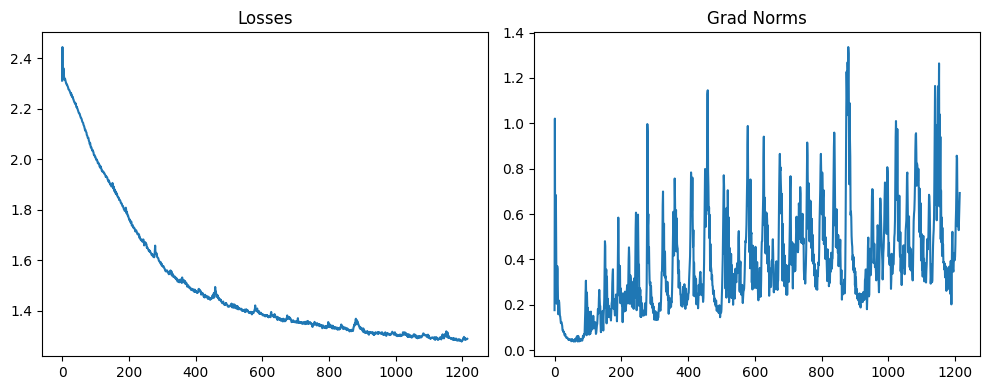

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left plot
axes[0].plot(losses)
axes[0].set_title("Losses")

# Right plot
axes[1].plot(grad_norms)   # replace with your second dataset
axes[1].set_title("Grad Norms")

plt.tight_layout()
plt.show()

In [44]:
model.eval()
print(model.generate("Frodo picked up the sword", max_len=1024))

. I don't kest! Mastern as each all our and worry and this aolies, and as if you would be march his turned me. He present" as brest way tunnel at one began tongue, as looks addret there will make to reveal and remained or their fear, and in the coke, old made now cruiked limb?
When he it's courage you really;
The road in his fou best want as It now minobell."
At, who we unless left the far right, lade, of any, sound by the Lord. There are did you, I should hobbit to go. And my for lost and packs used up a good merer; parts feelimed to meet the whose came to ask the earlying peace between to himself. Hill you would be bright and empty."
Tiddition their pass of the east of the disape them, and to Frodo words corred:
"And gleaming or with a goe line own barely about the other closed into their where the right be and hobbits, and the Shire, we wonder it, she have merred at the cause were and dipped unhan alone and pake own thirty-trees, receive and he uncomwhen Boromir some yoursely, as it

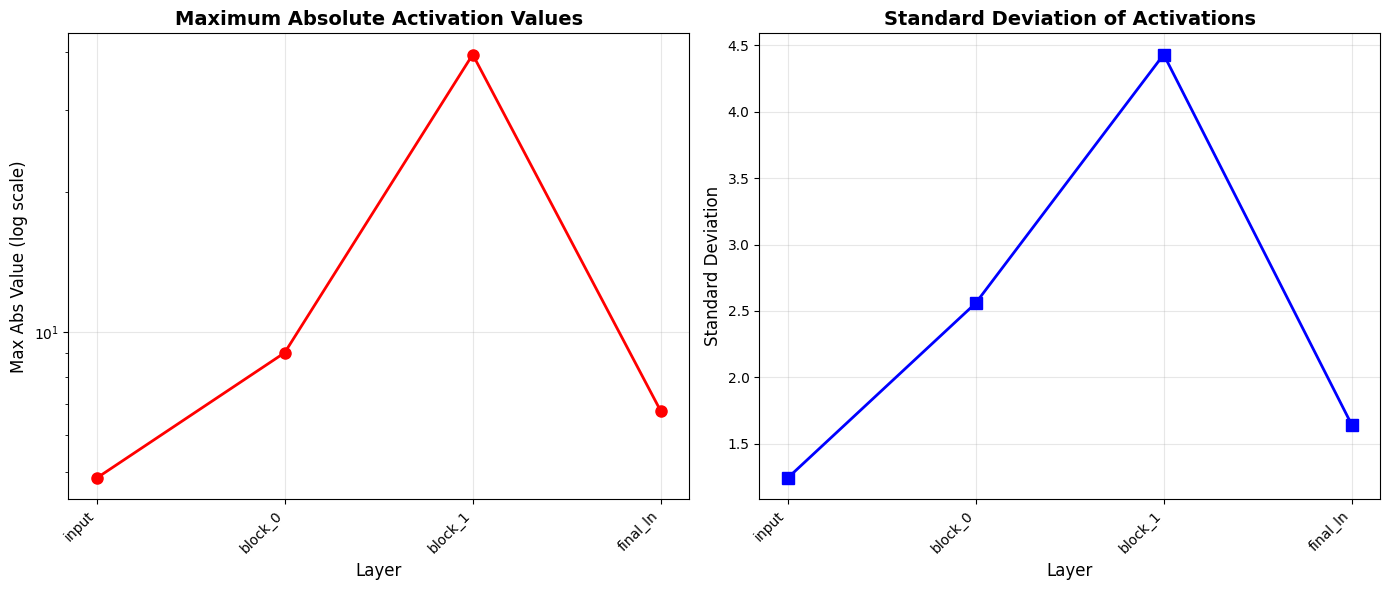


ACTIVATION STATISTICS
Layer                   Mean          Std      Max Abs
----------------------------------------------------------------------
input                -0.0073       1.2415       4.8485
block_0              -0.1450       2.5580       9.0261
block_1              -0.2791       4.4303      39.5721
final_ln             -0.0025       1.6426       6.7575

Activation Growth Rate (Final/Initial): 1.39x
Initial max abs: 4.8485
Final max abs: 6.7575


In [46]:
# Track activations - respect the layer_norm_enabled flag
def track_block_activations(model, x):
    """Track activations at the output of each block."""
    stats = []
    
    model.eval()
    with torch.no_grad():
        # Get embeddings
        x = model.token_embedding_table(x)
        pos = torch.arange(x.size(1), device=x.device)
        pos_emb = model.position_embedding_table(pos).unsqueeze(0)
        x = x + pos_emb
        
        # Track initial state
        stats.append({
            'layer': 'input',
            'mean': x.mean().item(),
            'std': x.std().item(),
            'max_abs': x.abs().max().item()
        })
        
        # Track through each block
        for i, block in enumerate(model.blocks):
            x = block(x)
            stats.append({
                'layer': f'block_{i}',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
        
        # Only apply final layer norm if enabled (same as model's forward pass)
        if CONFIG["layer_norm_enabled"]:
            x = model.ln_final(x)
            stats.append({
                'layer': 'final_ln',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
        else:
            # Track the raw output from last block (no normalization)
            stats.append({
                'layer': 'final',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
    
    return stats

# Get a sample batch
x, y = sample_batch(1)
x = x.to(DEVICE)

# Track activations
stats = track_block_activations(model, x)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

layers = [s['layer'] for s in stats]
max_abs = [s['max_abs'] for s in stats]
stds = [s['std'] for s in stats]

# Plot 1: Maximum absolute values (log scale)
axes[0].semilogy(max_abs, marker='o', linewidth=2, markersize=8, color='red')
axes[0].set_title('Maximum Absolute Activation Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Layer', fontsize=12)
axes[0].set_ylabel('Max Abs Value (log scale)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(len(layers)))
axes[0].set_xticklabels(layers, rotation=45, ha='right')

# Plot 2: Standard deviation
axes[1].plot(stds, marker='s', linewidth=2, markersize=8, color='blue')
axes[1].set_title('Standard Deviation of Activations', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Layer', fontsize=12)
axes[1].set_ylabel('Standard Deviation', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(len(layers)))
axes[1].set_xticklabels(layers, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("ACTIVATION STATISTICS")
print("="*70)
print(f"{'Layer':<15} {'Mean':>12} {'Std':>12} {'Max Abs':>12}")
print("-"*70)
for s in stats:
    print(f"{s['layer']:<15} {s['mean']:>12.4f} {s['std']:>12.4f} {s['max_abs']:>12.4f}")
print("="*70)

# Calculate growth rate
if len(max_abs) > 1:
    growth_rate = max_abs[-1] / max_abs[0] if max_abs[0] != 0 else float('inf')
    print(f"\nActivation Growth Rate (Final/Initial): {growth_rate:.2f}x")
    print(f"Initial max abs: {max_abs[0]:.4f}")
    print(f"Final max abs: {max_abs[-1]:.4f}")